In [1]:
from datasets import load_dataset, VerificationMode

name = "dasyd/OppQA"
splits = ["val", "train"]

ds = load_dataset(
    name,
    "binary",
    data_dir="binary",
    data_files={split: f"{split}-*" for split in splits},
    verification_mode=VerificationMode.NO_CHECKS,
    num_proc=len(splits),
)

Resolving data files:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

In [10]:
import matplotlib.pyplot as plt
import numpy as np
ds = ds.with_format("numpy")
d = ds["train"][0]
x = d["trajectory"]
q = d["question"]
a = d["answer"]
q, a

('The subject closed the Fridge After closing the front Door OR Before closing the front Door?',
 1)

In [11]:
import seaborn as sns
import pandas as pd

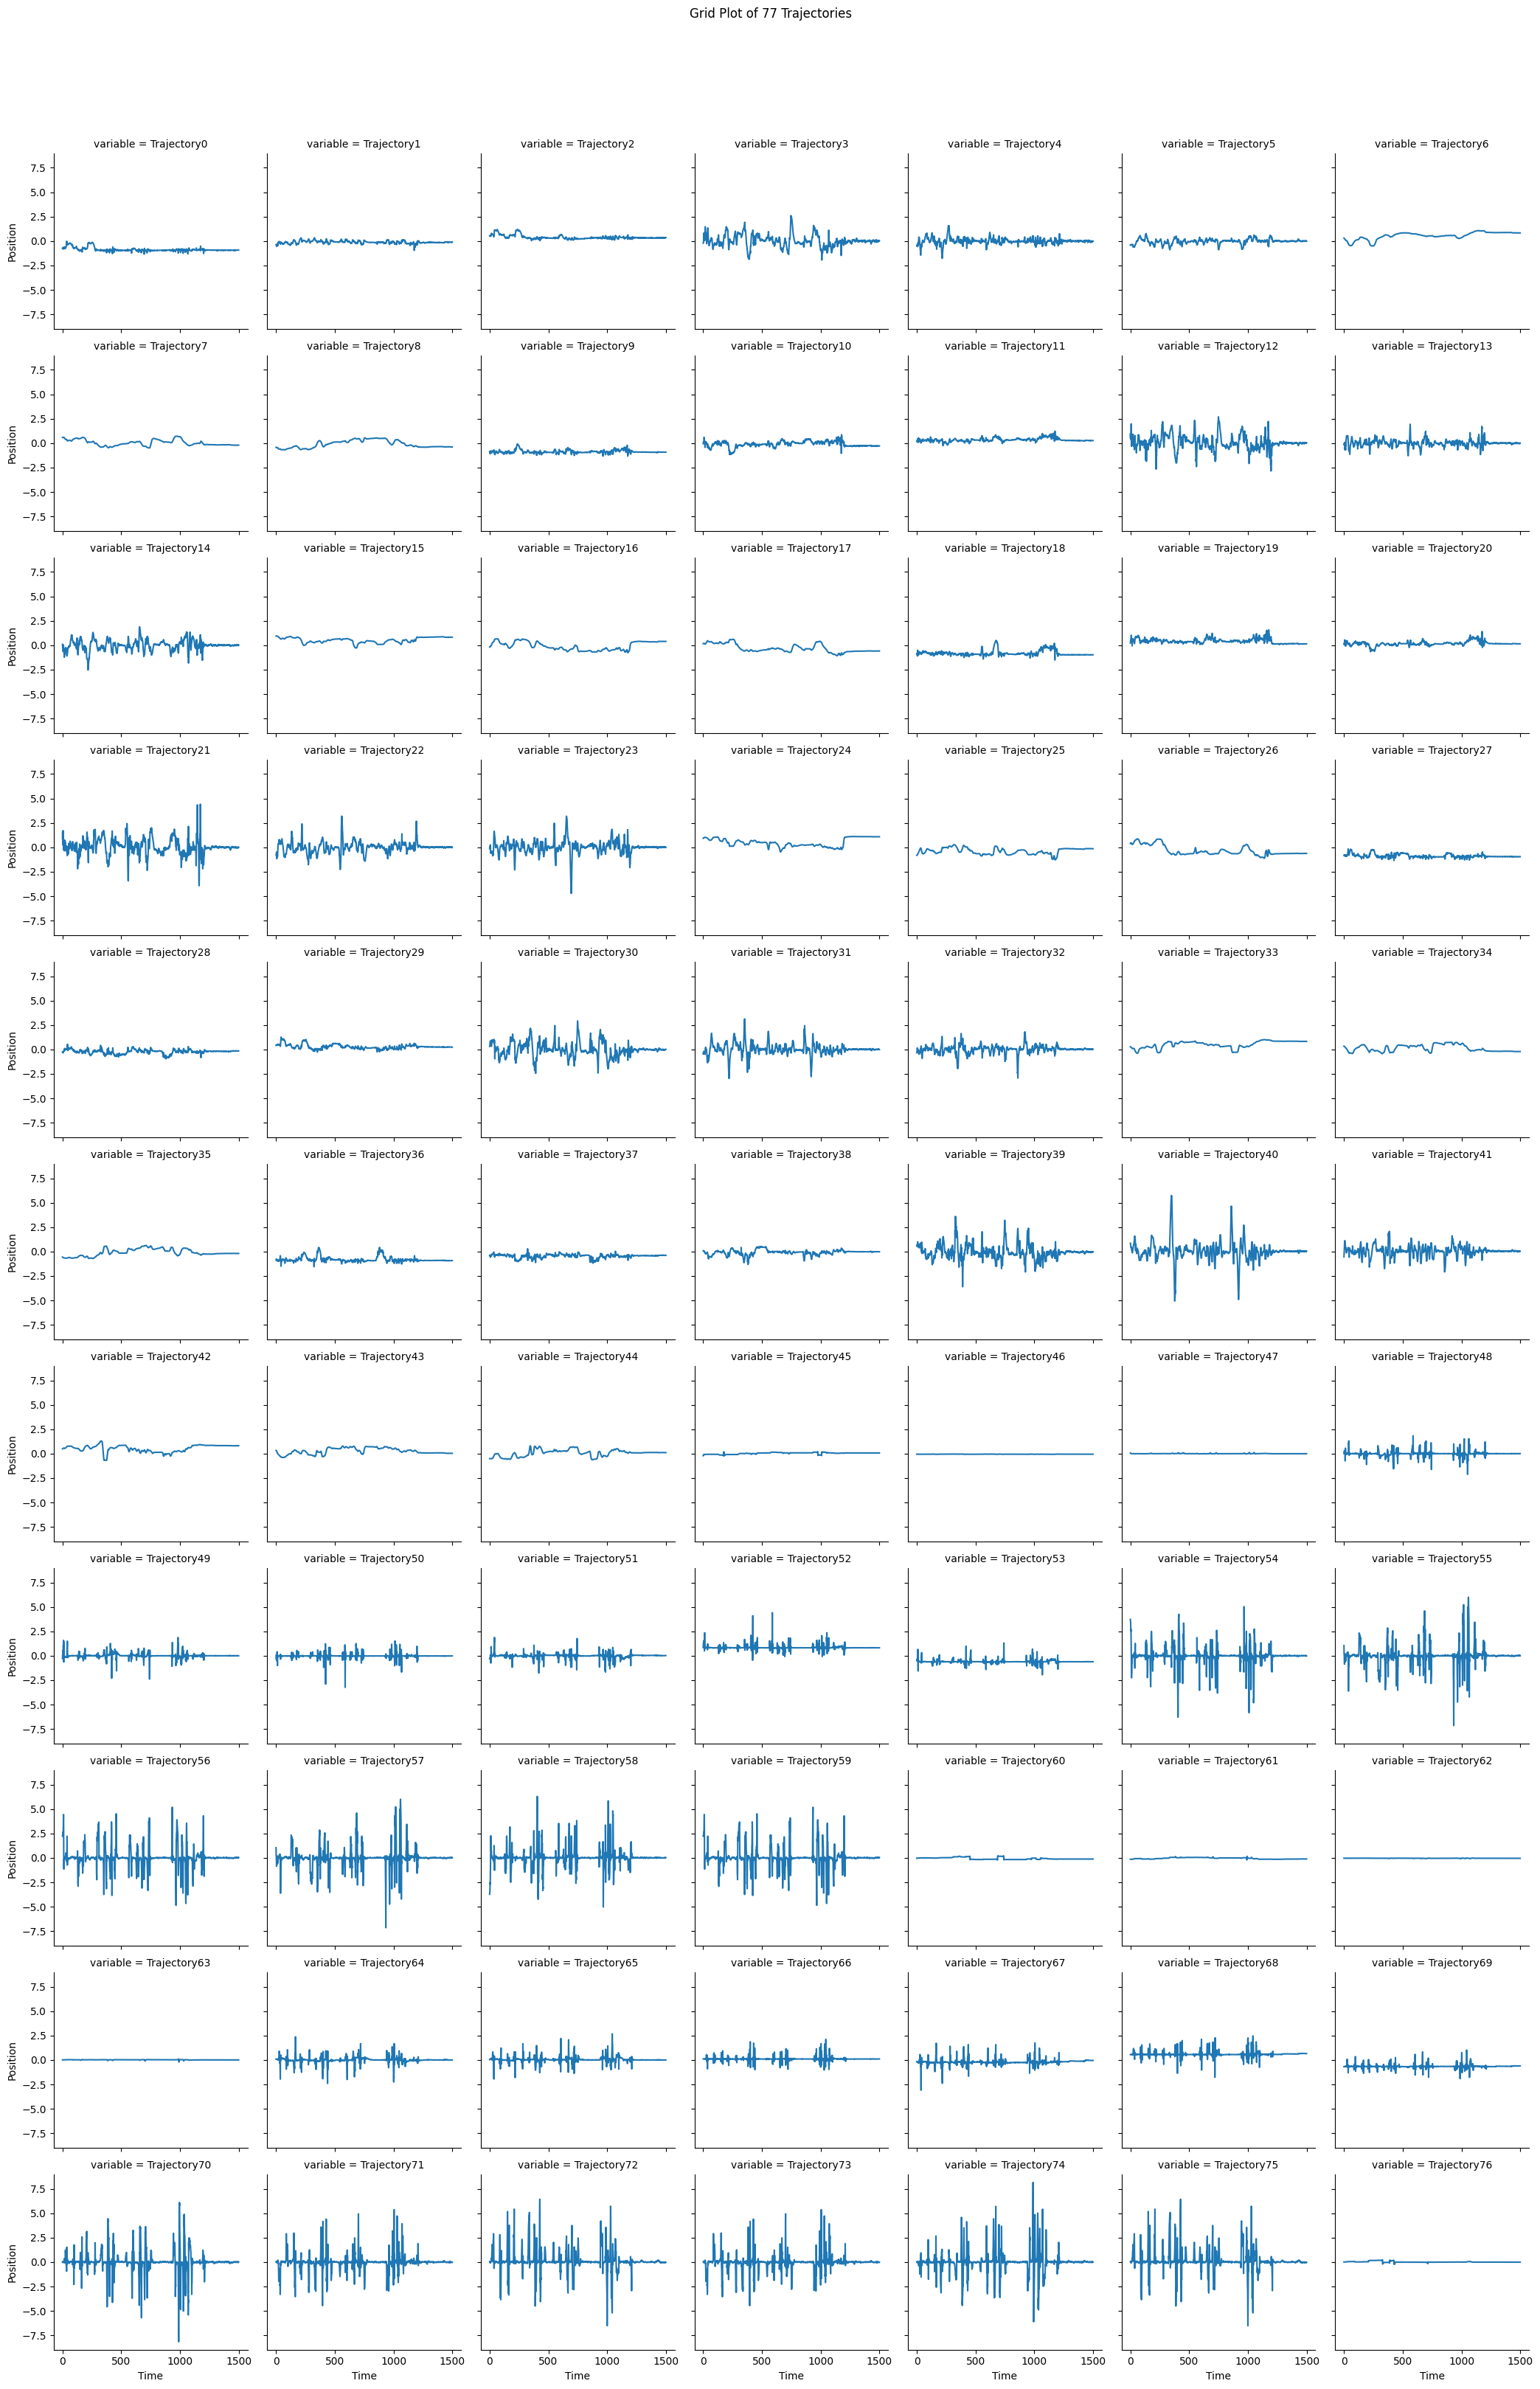

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Assuming df_trajectories is your DataFrame with each column being a trajectory
# Each row could be a time step; let's create a sample DataFrame for illustration.

time_steps = 1500
num_trajectories = 77


# Create a DataFrame where each trajectory is a column and each row is a timestep
df_trajectories = pd.DataFrame(x, columns=['Trajectory' + str(i) for i in range(num_trajectories)])

# Convert DataFrame to long format for use with sns.FacetGrid
df_long = df_trajectories.reset_index().melt(id_vars='index')
df_long.rename(columns={'index': 'Time', 'value': 'Position'}, inplace=True)

# Create a FacetGrid object with 77 plots in a grid
grid = sns.FacetGrid(df_long, col='variable', col_wrap=7, sharex=True, sharey=True)

# Map the line plots for each trajectory to the grid
grid.map(sns.lineplot, 'Time', 'Position')

# Set axis labels
grid.set_axis_labels('Time', 'Position')

# Add a title to the figure
plt.subplots_adjust(top=0.92)
grid.fig.suptitle('Grid Plot of 77 Trajectories')

# Show the plot
plt.show()
